# Osonye Onyemazuwa — Ad Spend Data
### Day 1-2: Created main branch README + Setup issues on Github + Acquire and load Ad Spend dataset

Data file: `ad_spend.csv` (place in a local `data/` folder, excluded via `.gitignore`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ad_spend.csv")
print(df.shape)
df.head()


(2599, 11)


,spend_id,date,campaign_id,channel,utm_source,utm_medium,utm_campaign,impressions,clicks,ad_spend,currency
0,SP000001,2021-10-25,1,Paid Search,google,cpc,campaign_01,35,2,10.00,USD
1,SP000002,2021-10-26,1,Paid Search,google,cpc,campaign_01,68,4,10.00,USD
2,SP000003,2021-10-27,1,Paid Search,google,cpc,campaign_01,68,3,10.00,USD
3,SP000004,2021-10-28,1,Paid Search,google,cpc,campaign_01,108,6,14.64,USD
4,SP000005,2021-10-29,1,Paid Search,google,cpc,campaign_01,73,4,10.00,USD


## Initial structure check

In [2]:
df.dtypes

spend_id            str
date                str
campaign_id       int64
channel             str
utm_source          str
utm_medium          str
utm_campaign        str
impressions       int64
clicks            int64
ad_spend        float64
currency            str
dtype: object

In [3]:
df.isna().sum()

spend_id        0
date            0
campaign_id     0
channel         0
utm_source      0
utm_medium      0
utm_campaign    0
impressions     0
clicks          0
ad_spend        0
currency        0
dtype: int64

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
spend_id,2599,2599,SP000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,2599,967,2023-04-09,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_id,2599.0,NaN,NaN,NaN,25.265102,14.635898,1.0,12.0,24.0,38.0,50.0
channel,2599,5,Affiliate,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_source,2599,5,affiliate_network,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_medium,2599,5,affiliate,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_campaign,2599,50,campaign_48,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
impressions,2599.0,NaN,NaN,NaN,134.573297,121.09083,14.0,61.0,98.0,163.0,1086.0
clicks,2599.0,NaN,NaN,NaN,3.687572,2.018611,1.0,2.0,3.0,5.0,20.0
ad_spend,2599.0,NaN,NaN,NaN,10.340993,2.049311,10.0,10.0,10.0,10.0,58.46


In [5]:
# Convert date from string to a real datetime type
df['date'] = pd.to_datetime(df['date'])
df.dtypes

spend_id                   str
date            datetime64[us]
campaign_id              int64
channel                    str
utm_source                 str
utm_medium                 str
utm_campaign               str
impressions              int64
clicks                   int64
ad_spend               float64
currency                   str
dtype: object

## Quick look: spend by channel

In [6]:
df.groupby('channel')['ad_spend'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)


,sum,mean,count
channel,,,
Affiliate,6454.96,10.165291,635
Paid Search,6150.75,11.102437,554
Email,5614.20,10.170652,552
Display,4480.00,10.000000,448
Social,4176.33,10.186171,410


## Quick look: date range

In [7]:
print("Earliest:", df['date'].min())
print("Latest:", df['date'].max())


Earliest: 2021-01-20 00:00:00
Latest: 2024-01-06 00:00:00


## Notes (local analysis log)

- Rows: 2,599, no missing values in any column (confirmed clean on delivery)
- Date range: 2021-01-20 to 2024-01-06
- `campaign_id` is numeric, joins cleanly to `campaigns.csv` (all 50 IDs used, no orphans either direction)
- No duplicate `spend_id` rows
- Spend by channel: **Affiliate (\$6,455)** > **Paid Search (\$6,151)** > **Email (\$5,614)** \> **Display (\$4,480)** \> **Social (\$4,176)**

Team-facing decisions/blockers from this analysis are tracked in the repo README, not duplicated here.


---
### Next steps (Day 3 — Issue #3)
- Standardize `channel` / `utm_source` casing to match `events.traffic_source`
- Decide with team how to handle Affiliate/Display spend attribution
- Check for duplicate `spend_id` rows


---
## Day 3 — Clean campaign IDs and standardize channel naming
**Issue #8:** Clean missing UTM parameters and inconsistent campaign IDs

Checked already:
- `campaign_id`: all 50 IDs match `campaigns.csv` exactly (no orphans either direction) — no cleaning needed here
- `spend_id`: no duplicates — no cleaning needed here
- No missing values anywhere in this file

Remaining real issue: `channel` values here don't match `events.traffic_source`
casing/naming, which will break the Week 2 SQL joins if not fixed now.


In [8]:
# Confirm campaign_id integrity (already checked, keeping as a documented test)
campaigns = pd.read_csv("campaigns.csv")

ad_ids = set(df['campaign_id'])
valid_ids = set(campaigns['campaign_id'])

orphans_in_spend = ad_ids - valid_ids
unused_campaigns = valid_ids - ad_ids

print("campaign_ids in ad_spend but not in campaigns.csv:", orphans_in_spend)
print("campaign_ids in campaigns.csv but never spent on:", unused_campaigns)
assert len(orphans_in_spend) == 0, "Found orphan campaign_ids -- investigate before Week 2"

campaign_ids in ad_spend but not in campaigns.csv: set()
campaign_ids in campaigns.csv but never spent on: set()


In [9]:
# Confirm no duplicate spend_id rows
dupes = df['spend_id'].duplicated().sum()
print(f"Duplicate spend_id rows: {dupes}")
assert dupes == 0, "Found duplicate spend_id rows -- dedupe before proceeding"

Duplicate spend_id rows: 0


### Standardize `channel` for downstream joins

`events.traffic_source` uses: Direct / Email / Organic / Paid Search / Social
(in multiple casings). `ad_spend.channel` uses: Affiliate / Display / Email /
Paid Search / Social.

Standardizing to lowercase + underscores now so this matches whatever
Member B does to `events.traffic_source` in their own cleaning step —
**worth confirming the exact convention with Member B before Day 4**,
so both sides land on the same format.

In [10]:
df['channel_clean'] = df['channel'].str.strip().str.lower().str.replace(' ', '_', regex=False)
df['utm_source_clean'] = df['utm_source'].str.strip().str.lower()

print(df['channel_clean'].unique())
print(df['utm_source_clean'].unique())

<ArrowStringArray>
['paid_search', 'email', 'display', 'social', 'affiliate']
Length: 5, dtype: str
<ArrowStringArray>
['google', 'email', 'google_display', 'meta', 'affiliate_network']
Length: 5, dtype: str


### Flag: Affiliate / Display have no equivalent in `events.traffic_source`

> This isn't something Day 3 can "clean away" — it's a team decision on how
> Affiliate and Display spend gets attributed (map to an existing category,
> or keep as a separate "unattributed spend" line). Documented in README;
> raising with team before Week 3 Fact table work.

In [11]:
# Save cleaned output locally (not committed -- .gitignore covers this)
import os
os.makedirs("cleaned", exist_ok=True)
df.to_csv("cleaned/ad_spend_clean.csv", index=False)
print("Saved cleaned/ad_spend_clean.csv:", df.shape)

Saved cleaned/ad_spend_clean.csv: (2599, 13)


---
## Day 4 — EDA on Ad Spend: spend by channel/campaign/day
**Issue #9:** EDA on Ad Spend: spend by channel/campaign/day; commit charts + notes.

In [12]:
df.head()

,spend_id,date,campaign_id,channel,utm_source,utm_medium,utm_campaign,impressions,clicks,ad_spend,currency,channel_clean,utm_source_clean
0,SP000001,2021-10-25,1,Paid Search,google,cpc,campaign_01,35,2,10.00,USD,paid_search,google
1,SP000002,2021-10-26,1,Paid Search,google,cpc,campaign_01,68,4,10.00,USD,paid_search,google
2,SP000003,2021-10-27,1,Paid Search,google,cpc,campaign_01,68,3,10.00,USD,paid_search,google
3,SP000004,2021-10-28,1,Paid Search,google,cpc,campaign_01,108,6,14.64,USD,paid_search,google
4,SP000005,2021-10-29,1,Paid Search,google,cpc,campaign_01,73,4,10.00,USD,paid_search,google


### Spend by channel

In [13]:
spend_by_channel = df.groupby('channel_clean')['ad_spend'].sum().sort_values(ascending=False)
spend_by_channel

channel_clean
affiliate      6454.96
paid_search    6150.75
email          5614.20
display        4480.00
social         4176.33
Name: ad_spend, dtype: float64

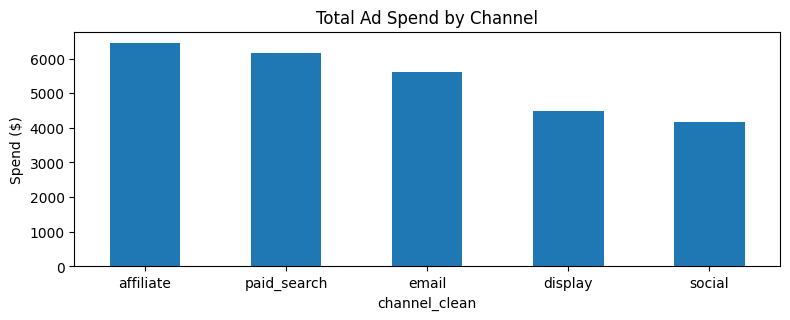

In [14]:
spend_by_channel.plot(kind='bar', figsize=(8,4), title='Total Ad Spend by Channel')
plt.ylabel('Spend ($)')
plt.tight_layout()
plt.xticks(rotation=0)
plt.savefig('spend_by_channel.png')
plt.show()

### Spend by campaign (top 10)

In [15]:
spend_by_campaign = df.groupby('campaign_id')['ad_spend'].sum().sort_values(ascending=False)
spend_by_campaign.head(10)

campaign_id
48    1001.70
23     980.97
26     844.39
5      842.55
9      835.72
13     830.00
22     803.92
44     775.26
11     756.00
4      750.00
Name: ad_spend, dtype: float64

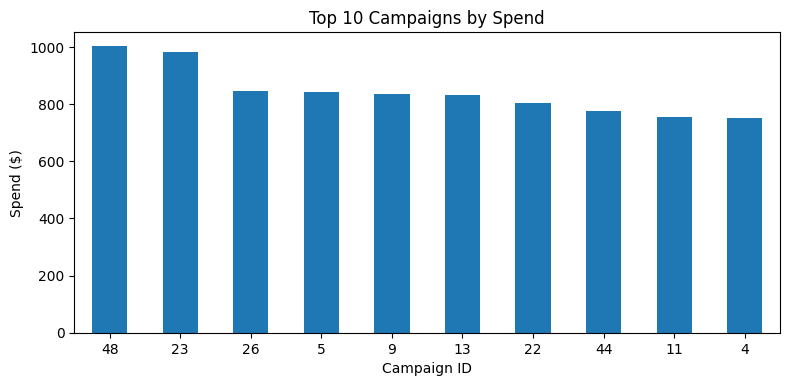

In [16]:
spend_by_campaign.head(10).plot(kind='bar', figsize=(8,4), title='Top 10 Campaigns by Spend')
plt.ylabel('Spend ($)')
plt.xlabel('Campaign ID')
plt.tight_layout()
plt.xticks(rotation=0)
plt.savefig('top10_campaigns.png')
plt.show()

### Spend over time (daily)

In [17]:
spend_by_day = df.groupby(df['date'].dt.date)['ad_spend'].sum()
spend_by_day.describe()

count    967.000000
mean      27.793423
std       13.202146
min       10.000000
25%       20.000000
50%       25.130000
75%       40.000000
max       78.360000
Name: ad_spend, dtype: float64

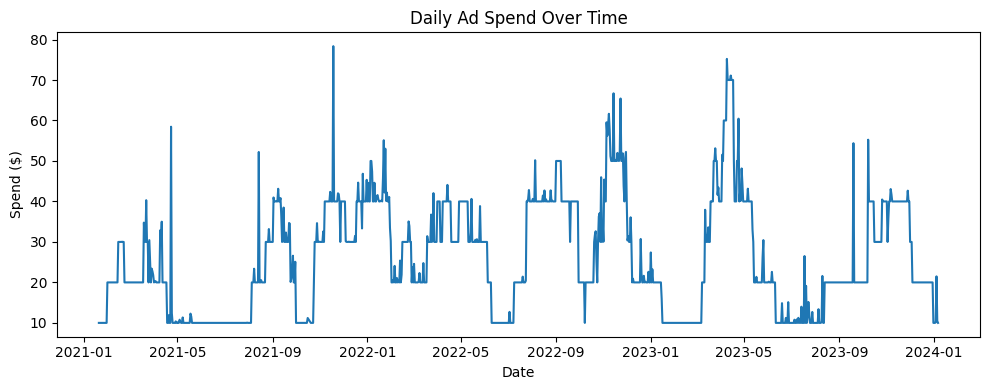

In [18]:
spend_by_day.plot(figsize=(10,4), title='Daily Ad Spend Over Time')
plt.ylabel('Spend ($)')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('daily_spend_trend.png')
plt.show()

### Day 4 notes

> - Highest-spend channel: Affiliate; lowest: Social
> - Campaign #48 is the single highest-spend campaign **(\$1,001.70)** — worth checking
>  if it's genuinely a bigger campaign or a possible outlier for Day 5
> - Daily spend ranges from **\$10** (single min-spend day) to **\$78.36** (busiest day), averaging **~\$27.79/day** across 967 active spend-days
> - Clear cyclical pattern — spend alternates between low-baseline periods **(~$10/day)** and higher bursts every few months, rather than being random. Worth checking in Day 5 whether these bursts align with specific campaigns.csv start/end dates.

---
## Day 5 — Identify and flag outlier/suspicious spend entries
**Issue #10:** Identify and flag outlier/suspicious spend entries.


### First pass: revisit Campaign #48 (yesterday's flag)

In [22]:
campaign_48 = df[df['campaign_id'] == 48]
print("Campaign #48 rows:", len(campaign_48))
print("Total spend:", campaign_48['ad_spend'].sum())
campaign_48[['date', 'ad_spend', 'clicks', 'impressions']].describe()

Campaign #48 rows: 90
Total spend: 1001.7


,date,ad_spend,clicks,impressions
count,90,90.000000,90.000000,90.000000
mean,2022-02-18 12:00:00,11.130000,3.722222,67.566667
min,2022-01-05 00:00:00,10.000000,1.000000,14.000000
25%,2022-01-27 06:00:00,10.000000,2.000000,38.000000
50%,2022-02-18 12:00:00,10.000000,3.000000,59.000000
75%,2022-03-12 18:00:00,10.265000,5.000000,86.500000
max,2022-04-04 00:00:00,22.640000,10.000000,184.000000
std,NaN,2.642922,2.028049,38.658124


> **Finding:** Campaign #48's high total **(\$1,001.70)** is NOT a single suspicious
> entry — it's 90 separate spend rows (Jan-Apr 2022), each mostly at the \~$10
> baseline. It's simply the longest-running campaign in the dataset, not an
> anomaly. Clearing this flag from Day 4.